In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import random
import typing

Text(0, 0.5, 'Y')

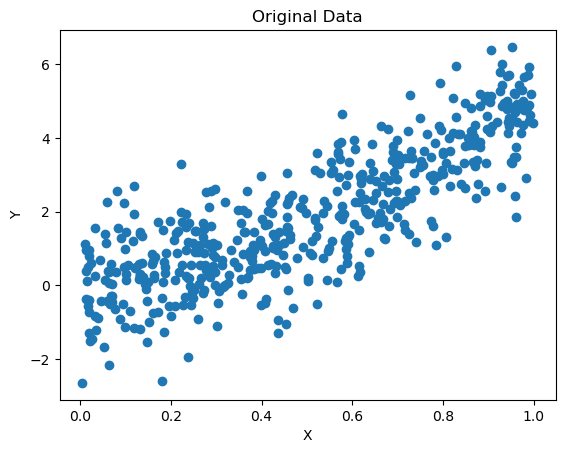

In [2]:
# Data Generation
np.random.seed(0)
n = 500     # sample size
X = np.random.uniform(0, 1, n)
epsilon = np.random.normal(0, 1, n)
a, b, c = 2, 3, 1
Y = a * X + b * X ** 2 + epsilon
plt.scatter(X, Y)
plt.title("Original Data")
plt.xlabel("X")
plt.ylabel("Y")

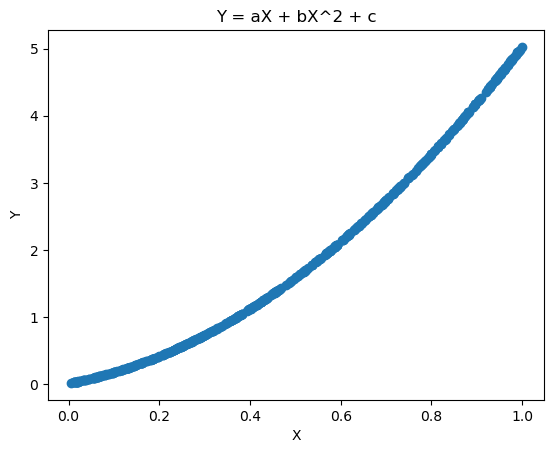

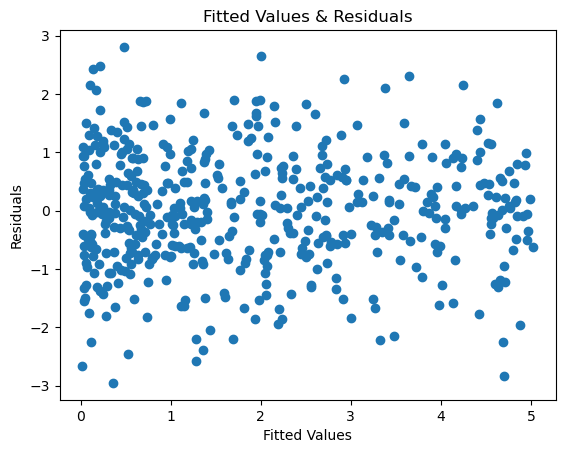

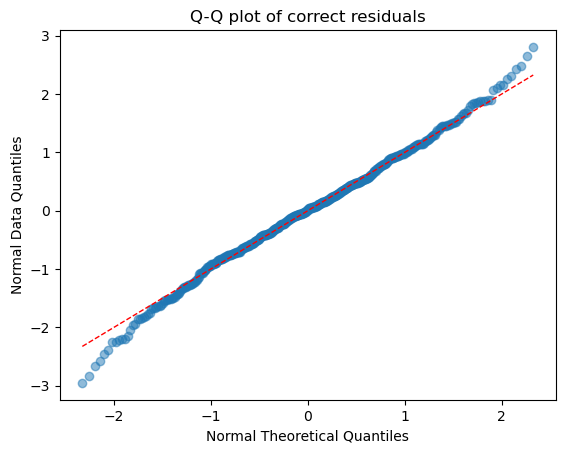

In [3]:
### Task 1

# 设计矩阵: 1, X, X^2
X_design = np.column_stack((np.ones(n), X, X ** 2))
# 最小二乘解 beta = (X'X)^{-1} X'Y
XtX = X_design.T @ X_design
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ (X_design.T @ Y)

Y_fit = X_design @ beta
residuals = Y - Y_fit
res_sorted = np.sort(residuals)

# X, Y_fit
plt.figure()
plt.scatter(X, Y_fit)
plt.title("Y = aX + bX^2 + c")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# residuals, Y_fit
plt.figure()
plt.scatter(Y_fit, residuals)
plt.title("Fitted Values & Residuals")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()

# Q-Q plot of residuals
quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n))  # 为避免无穷，取0.01~0.99
plt.figure()
plt.scatter(quantiles, res_sorted, alpha=0.5)
plt.plot([quantiles.min(), quantiles.max()], [quantiles.min(), quantiles.max()], 'r--', linewidth=1)
plt.xlabel('Normal Theoretical Quantiles')
plt.ylabel('Normal Data Quantiles')
plt.title('Q-Q plot of correct residuals')
plt.show()

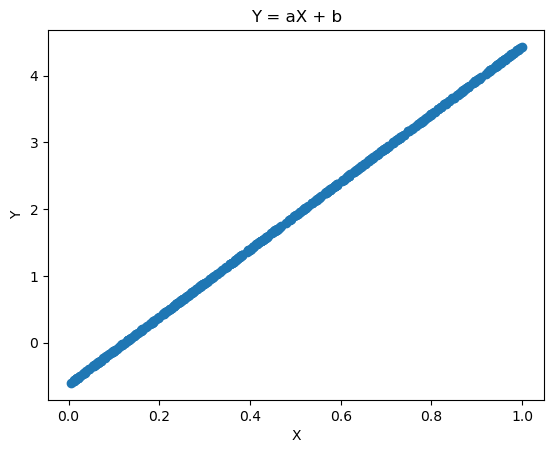

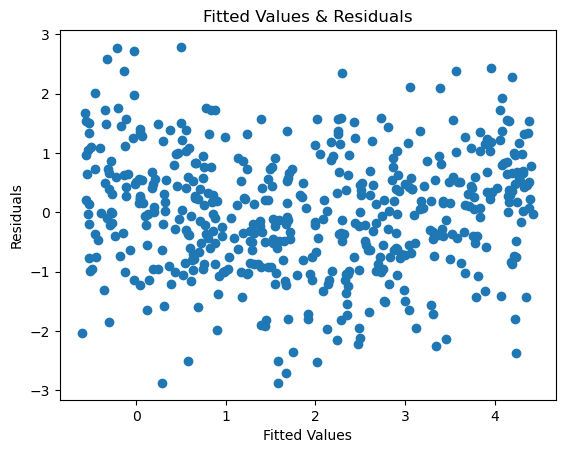

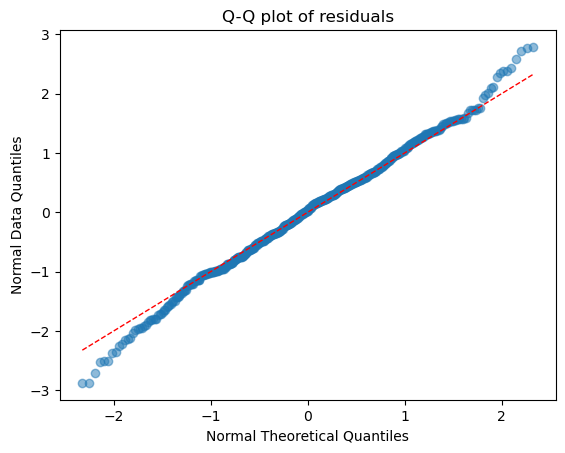

In [4]:
### Task 2

# parameters
a_hat = np.sum((X - np.mean(X)) * (Y - np.mean(Y))) / np.sum((X - np.mean(X)) ** 2)
b_hat = np.mean(Y) - a_hat * np.mean(X)

Y_fit = a_hat * X + b_hat
residuals = Y - Y_fit
res_sorted = np.sort(residuals)

# X, Y_fit
plt.figure()
plt.scatter(X, Y_fit)
plt.title("Y = aX + b")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

# Y_fit, residuals
plt.scatter(Y_fit, residuals)
plt.title("Fitted Values & Residuals")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals") 
plt.show()

# Q-Q plot of residuals
quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n))  # 为避免无穷，取0.01~0.99
plt.figure()
plt.scatter(quantiles, res_sorted, alpha=0.5)
plt.plot([quantiles.min(), quantiles.max()], [quantiles.min(), quantiles.max()], 'r--', linewidth=1)
plt.xlabel('Normal Theoretical Quantiles')
plt.ylabel('Normal Data Quantiles')
plt.title('Q-Q plot of residuals')
plt.show()


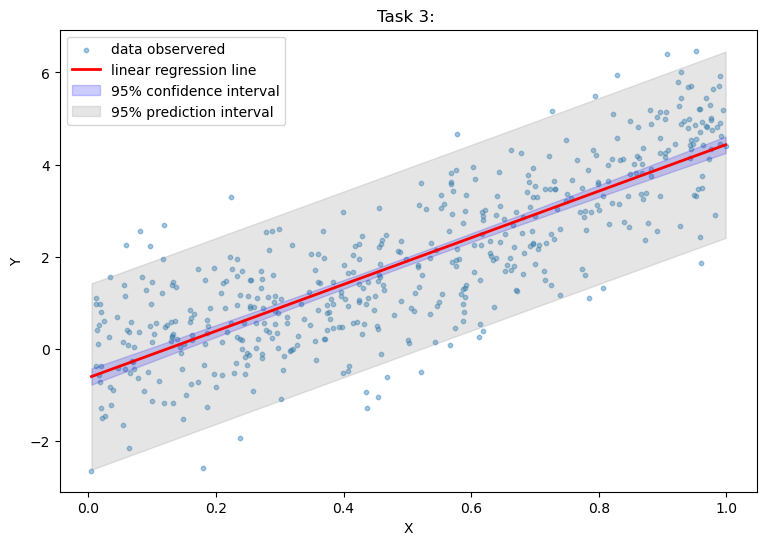

In [5]:
# Task 3

n = len(X)
x_bar = np.mean(X)
Sxx = np.sum((X - x_bar) ** 2)
sigma_hat = np.sqrt(np.sum(residuals ** 2) / (n - 2))

# t 临界值 (95% 置信水平，双尾)
from scipy.stats import t
t_crit = t.ppf(0.975, df=n-2) 

# 生成一组 X0 用于画图
X0 = np.linspace(min(X), max(X), 200)
y0_hat = a_hat * X0 + b_hat

# 均值的标准误
se_mean = sigma_hat * np.sqrt(1/n + (X0 - x_bar)**2 / Sxx)
# 预测的标准误 (包含个体误差)
se_pred = sigma_hat * np.sqrt(1 + 1/n + (X0 - x_bar)**2 / Sxx)

# 置信区间和预测区间
ci_lower = y0_hat - t_crit * se_mean
ci_upper = y0_hat + t_crit * se_mean
pi_lower = y0_hat - t_crit * se_pred
pi_upper = y0_hat + t_crit * se_pred

plt.figure(figsize=(9, 6))
plt.scatter(X, Y, alpha=0.4, s=10, label='data observered')
plt.plot(X0, y0_hat, 'r-', linewidth=2, label='linear regression line')
plt.fill_between(X0, ci_lower, ci_upper, color='blue', alpha=0.2, label='95% confidence interval')
plt.fill_between(X0, pi_lower, pi_upper, color='gray', alpha=0.2, label='95% prediction interval')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Task 3: ')
plt.legend()
plt.show()